## Vericación de las bibliotecas del curso

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import sklearn
import scipy

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

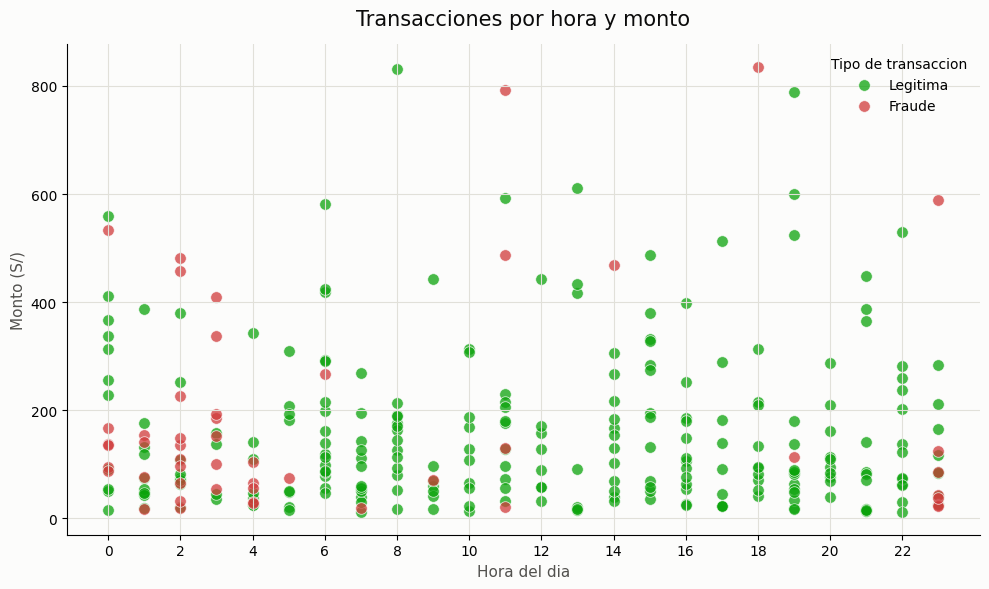

Total transacciones: 300 | Fraudes: 50


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
n = 300
hora = np.random.randint(0, 24, n)
monto = np.random.exponential(scale=150, size=n) + 10
# Fraude mas probable de madrugada (0-5h, 23h) y en montos altos
prob_fraude = 0.03 + 0.35 * ((hora <= 5) | (hora >= 23)) + 0.25 * (monto > 400)
prob_fraude = np.clip(prob_fraude, 0, 0.9)
es_fraude = (np.random.rand(n) < prob_fraude).astype(int)
transacciones = pd.DataFrame({"hora": hora, "monto": monto, "es_fraude": es_fraude})
colores = {0: "#0ca30c", 1: "#d03b3b"} # verde = legitima, rojo = fraude
etiquetas = {0: "Legitima", 1: "Fraude"}
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for valor in [0, 1]:
    subset = transacciones[transacciones["es_fraude"] == valor]
    ax.scatter(
        subset["hora"], subset["monto"],
        s=70, alpha=0.75,
        c=colores[valor],
        edgecolors="white", linewidths=0.6,
        label=etiquetas[valor],
    )
ax.set_title("Transacciones por hora y monto", fontsize=15, color="#0b0b0b", pad=14)
ax.set_xlabel("Hora del dia", fontsize=11, color="#52514e")
ax.set_ylabel("Monto (S/)", fontsize=11, color="#52514e")
ax.set_xticks(range(0, 24, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Tipo de transaccion", frameon=False, loc="upper right")
plt.tight_layout()
plt.show()
print("Total transacciones:", len(transacciones),
    "| Fraudes:", transacciones["es_fraude"].sum())

## GATO